# 필요한 라이브러리 설치

In [1]:
%pip install -q langchain-openai python-dotenv langgraph langchain langchain-classic langchain-community pypdf docx2txt py-zerox


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q langchain-text-splitters pymupdf "unstructured[md]" nltk langchain-anthropic


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 환경변수 적용 및 모델 설정 

In [3]:
from dotenv import load_dotenv 
from langchain.chat_models.base import init_chat_model

load_dotenv()

MODEL_NAME = "gpt-5"

llm = init_chat_model(MODEL_NAME, model_provider="openai")

# Text Splitter 설정 및 마크다운 로더 적용

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)

In [5]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader

markdown_path = "./documents/meeting.md"
loader = UnstructuredMarkdownLoader(markdown_path)
document_list = loader.load_and_split(text_splitter)

In [6]:
def load_document(state):

    file_path = state["file_path"]
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()
    
    return {"text": text, "file_path": file_path}

# 문서 타입 분류 노드

In [7]:
def classify_document(state):
    text = state["text"][:2000]

    prompt = f"""
    아래 문서의 성격을 분류하세요.

    [가능한 카테고리: "회의록", "기술 회의", "회고록"]
    1. 회의록 
        - 일정, 기획, 진행상황, 업무 조율 등 '회의 중 논의된 내용' 중심의 문서
        - 예시: "다음 스프린트 일정은 10월 5일로 확정했다.", "요구사항 명세 변경에 대한 논의"
    2. 기술 회의
        - 시스템 구조, 아키텍처 설계, 성능 개선, 기술 스택, API 설계 등
        - 예시: "Redis 캐시 구조 변경", "DB 인덱스 튜닝", "Spring Boot 구조 개선 논의"
        - '성능 개선', '기술 검토', '아키텍처', '리팩토링' 등의 단어가 포함된 경우 기술 회의로 분류
    3. 회고록
        - 지난 기간 동안의 활동을 되돌아보며 배운 점, 잘한 점, 아쉬운 점 등을 서술하는 문서
        - 예시: "이번 스프린트에서 협업의 중요성을 느꼈다.", "성과와 개선점을 공유하며 회고를 진행했다."
        - '지난 프로젝트', '이번 스프린트 회고', '느낀 점', '배운 점' 등의 단어가 포함된 경우 회고록으로 분류

    [분류 규칙]
    - 문서에 '성능 개선', 'API 설계', '기술 검토', 'DB', '서버', '아키텍처' 등의 단어가 포함되어 있다면 → 기술 회의로 분류
    - 문서에 '일정', '회의', '기획', '참석자', '논의' 등의 단어가 주로 등장하면 → 회의록으로 분류
    - 문서에 '회고', '지난', '성과', '느낀 점', '배운 점'이 등장하고, 과거 시제의 문장이 많다면 → 회고록으로 분류
    - 만약 두 가지 이상 혼합되어 있으면, 기술 관련 논의가 포함된 경우 기술 회의로 우선 분류

    [출력 형식]
    문서 유형: "회의록" 또는 "기술 회의" 또는 "회고록"

    ---
    [문서 내용]
    {text}
    """

    result = llm.invoke(prompt)
    answer = result.content.strip()
    print(f"📝 분류 결과: {answer}")
    print("============================")
    doc_type = None

    for c in ["회의록", "기술 회의", "회고록"]:
        if c in answer:
            doc_type = c
            break

    if not doc_type:
        doc_type = "미분류"
        print("⚠️ 분류 실패: 기본값 '미분류'로 처리합니다.")
    
    print(f"✅ 문서 분류 완료: {doc_type}")
    return {
        "doc_type": doc_type,
        "text": state["text"],
        "file_path": state["file_path"]
    }

# 타입별 프롬프트 정의 노드

# 회의록 타입 노드

In [8]:
from langchain_core.prompts import PromptTemplate

def node_meeting(state):

    with open("./templates/meeting_template.txt", "r", encoding="utf-8") as f:
        template_str = f.read()

    prompt = PromptTemplate(input_variables=["context"], template=template_str)
    formatted_prompt = prompt.format(context=state["text"])

    result = llm.invoke(formatted_prompt)
    print(f"✅ 회의록 생성 완료")
    return {"md_content": result.content, **state}


# 회고록 타입 노드

In [9]:
from langchain_core.prompts import PromptTemplate

def node_retrospective(state):

    with open("./templates/retrospective_template.txt", "r", encoding="utf-8") as f:
        template_str = f.read()

    prompt = PromptTemplate(input_variables=["context"], template=template_str)
    formatted_prompt = prompt.format(context=state["text"])

    result = llm.invoke(formatted_prompt)
    print(f"✅ 회고록 생성 완료")
    return {"md_content": result.content, **state}

# 기술 공유 노드 

In [10]:
from langchain_core.prompts import PromptTemplate

def node_techshare(state):

    with open("./templates/tech_review_template.txt", "r", encoding="utf-8") as f:
        template_str = f.read()

    prompt = PromptTemplate(input_variables=["context"], template=template_str)
    formatted_prompt = prompt.format(context=state["text"])

    result = llm.invoke(formatted_prompt)
    print(f"✅ 기술 회의록 생성 완료")
    return {"md_content": result.content, **state}

# 결과 저장 노드 

In [11]:
from pathlib import Path
from datetime import datetime

def save_markdown(state):
    output_dir = Path("outputs")
    output_dir.mkdir(exist_ok=True)

    base_name = Path(state["file_path"]).stem
    filename = f"{base_name}_{state['doc_type']}_{datetime.now().strftime('%Y%m%d_%H%M')}.md"
    file_path = output_dir / filename

    with open(file_path, "w", encoding="utf-8") as f:
        f.write(state["md_content"])

    print(f"✅ Markdown 문서 저장 완료: {file_path}")
    return {"file_path": str(file_path), "doc_type": state["doc_type"]}


# LangGraph 워크플로우 정의 

In [12]:
from langgraph.graph import StateGraph, END

# 상태 정의
from typing import TypedDict
class DocState(TypedDict):
    text: str
    file_path: str
    doc_type: str
    md_content: str

# 그래프 구성
graph = StateGraph(DocState)
graph.add_node("LoadDoc", load_document)
graph.add_node("Classify", classify_document)
graph.add_node("MeetingNode", node_meeting)
graph.add_node("TechShareNode", node_techshare)
graph.add_node("RetrospectiveNode", node_retrospective)
graph.add_node("Save", save_markdown)

graph.add_edge("LoadDoc", "Classify")

# 문서 타입별 분기
graph.add_conditional_edges(
    "Classify",
    lambda state: state["doc_type"],
    {
        "회의록": "MeetingNode",
        "기술 회의": "TechShareNode",
        "회고록": "RetrospectiveNode",
    }
)

graph.add_edge("MeetingNode", "Save")
graph.add_edge("TechShareNode", "Save")
graph.add_edge("RetrospectiveNode", "Save")

graph.set_entry_point("LoadDoc")
graph.set_finish_point("Save")

app = graph.compile()

# 테스트

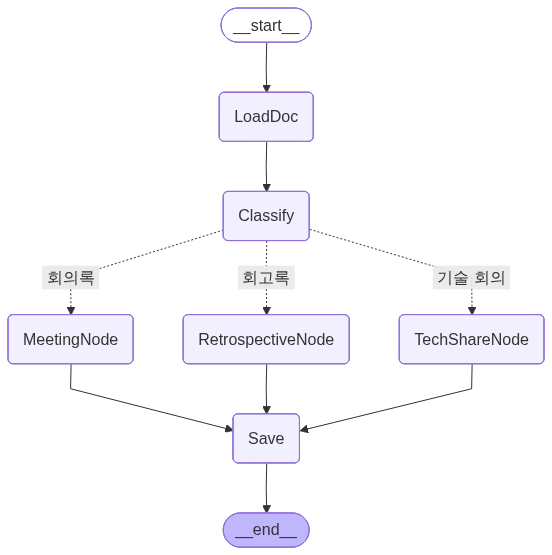

In [13]:
from IPython.display import Image, display 

display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
result = app.invoke({"file_path": "./documents/meeting.md"})
print(result)

📝 분류 결과: 문서 유형: "회고록"
✅ 문서 분류 완료: 회고록
✅ 회고록 생성 완료
✅ Markdown 문서 저장 완료: outputs/meeting_회고록_20251028_1300.md
{'text': "# 회고\n\n태그: 회고\n날짜: 2025/09/12\n\n### 좋았던 점(Good)\n\n용범\n\n- 우선, 정말 뜻 깊은 한 주를 보낸 것 같아서 너무 뿌듯한 마음입니다. 간식을 모두와 함께 먹으며, 당이 떨어지지 않는 환경 속에서 개발을 할 수 있어서 좋았습니다. 모두 건강했으면 좋겠습니다.\n- 김나영 교육생의 발표 실력에 감탄을 금치 못했습니다.\n- 연지윤 교육생의 PPT 구성 실력에 감탄을 금치 못했습니다.\n- 배울 점이 많습니다.\n\n예림 \n\n- 요즘 지각 안하려고 20분 일찍 오고 있습니다!\n- AI는 아니지만 공부하면서 LLM, 랭체인, 라그, 각종 알고리즘 등 알게 되어서 좋았습니다. 요즘 공고에 AI 해본 백엔드 우대사항이 정말 많더라고요 …\n- 간식이 많아져서 행복합니다. 용범님의 애정? 감사합니다.\n- 같이 감자빵 사러 가는 거 약간 힐링입니다.\n- 나영님의 발표가 인상 깊었습니다.\n- 지윤님과 주혜님의 주도하에 PPT가 예쁘게 만들어졌습니다.\n- 이번 주도 마찬가지로 주혜님이 귀엽습니다.\n- 코어 시간은 스스로 잘 지키고 있는 것 같습니다!\n\n의균 \n\n- 다들 많이 도와주셔서 편했습니다.\n- 간식 많아서 좋네요\n\n나영\n\n- 그래도 중간발표가 끝났어요….작은 산 하나 넘은 느낌\n\n지윤 \n\n- 스토리북이라는 새로운 기술(?) 도입, 나름 성공적으로 활용한 것 같아 뿌듯하다.\n- vscode에서 ai 쓰니까 개발 속도가 다르다.\n- 간식이 많아져서 풍족하고 좋았다.\n- 발표 자료 만들 때 이런저런 효과 넣으면서 재밌었다.\n- 날이 선선해져서 출퇴근할 때도 좋고, 점심 먹고 산책하기도 좋다.\n\n주혜 \n\n- 스토리북 1차로 완성한 것 좋았다\n- 날도 좋고 간식도 맛있다!\